# Linear Regression Using Gradient Descent

This program trains a **Linear Regression** model from scratch.

## Steps

1. Create the training data.
2. Initialize random values for **Weight (`w`)** and **Bias (`b`)**.
3. Predict the output using:

$$
\hat{y} = wx + b
$$

4. Calculate the prediction error.
5. Update `w` and `b` using **Gradient Descent**.
6. Calculate the **Mean Squared Error (MSE)**.
7. Repeat until the error becomes very small or the maximum number of epochs is reached.

## Output

- Original data points
- Best-fit regression line
- Cost (MSE) vs. Epochs graph
- Final values of `w`, `b`, and the cost

<details>
<summary><b>Deep Comparison: Batch GD vs SGD vs Mini-Batch GD</b></summary>



All three algorithms have the **same goal**: minimize the cost function by finding the best **weight (`w`)** and **bias (`b`)**.

The only difference is **how much data is used before updating the model parameters**.

| Method | Data Used per Update | Updates per Epoch |
|---------|----------------------|------------------:|
| **Batch GD** | Entire dataset | 1 |
| **SGD** | One sample | Number of samples |
| **Mini-Batch GD** | Small batch (e.g., 32, 64) | Number of batches |

## Batch Gradient Descent (BGD)

The model uses **all training samples** to calculate the gradients, then updates `w` and `b` **once**.

**Advantages**
- Stable and smooth updates.
- Accurate gradient direction.

**Disadvantages**
- Slow on large datasets.
- Requires more memory.

---

## Stochastic Gradient Descent (SGD)

The model updates `w` and `b` **after every single training sample**.

**Advantages**
- Very fast updates.
- Low memory usage.
- Suitable for very large datasets.

**Disadvantages**
- Noisy updates.
- The cost fluctuates and convergence is less stable.

---

## Mini-Batch Gradient Descent (MBGD)

The dataset is divided into **small batches** (e.g., 32 or 64 samples). The model updates its parameters after processing each batch.

**Advantages**
- Faster than Batch GD.
- More stable than SGD.
- Efficient memory usage.
- Most widely used in modern Machine Learning and Deep Learning.

**Disadvantages**
- Slightly noisy compared to Batch GD.

---

## Example

Suppose the dataset contains **1000 samples**.

- **Batch GD:** 1000 samples → **1 update**
- **SGD:** 1 sample → **1000 updates**
- **Mini-Batch GD (batch size = 100):** 100 samples → **10 updates**

## Easy Way to Remember

- **Batch GD:** Read the **entire book**, then make one decision.
- **SGD:** Read **one page**, then make a decision.
- **Mini-Batch GD:** Read **one chapter**, then make a decision.


</details>


Initial w = 0.4360
Initial b = 0.0259


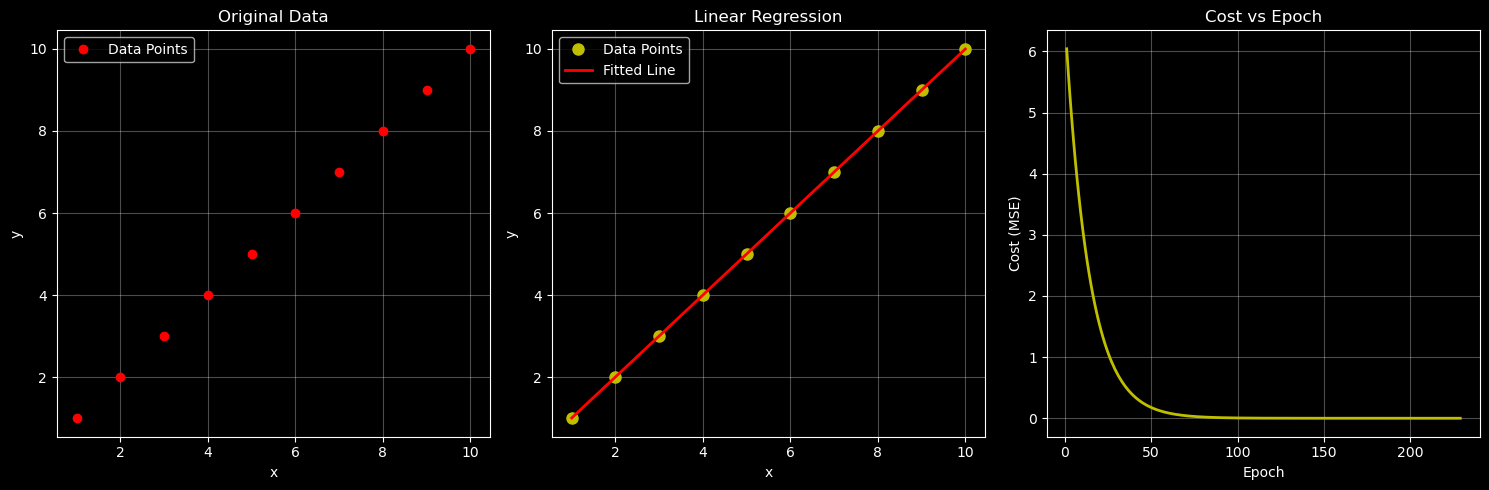


Final w = 0.9988
Final b = 0.0094
Final cost = 0.000010
Training stopped at epoch = 229


In [ ]:

#--------------BATCH GRADIENT DESCENT------------------

import numpy as np
import matplotlib.pyplot as plt

# DATA
x = np.arange(1, 11)
y = np.arange(1, 11)


# Figure
plt.figure(figsize=(15, 5), dpi=100)

# Original data
plt.subplot(1, 3, 1)
plt.plot(x, y, 'o', color='red', markersize=6, label='Data Points')
plt.title("Original Data")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.legend()


np.random.seed(2)

w = np.random.rand()
b = np.random.rand()


print(f"Initial w = {w:.4f}")
print(f"Initial b = {b:.4f}")


eta = 0.05
epochs = 1000

costVal = np.zeros(epochs)

# Gradient Decsent
for i in range(epochs):

    # Prediction
    yhat = w * x + b

    # Error
    error = yhat - y

    # Gradients
    dw = np.mean(error * x)
    db = np.mean(error)

    # new weight and Bias 
    w = w - eta * dw
    b = b - eta * db


    # Mean Squared Error Cost
    costVal[i] = 0.5 * np.mean((yhat - y) ** 2)

    # Stop if converged
    if costVal[i] < 1e-5:
        break

# -----------------------------
# Regression line
# -----------------------------
plt.subplot(1, 3, 2)

# Data points
plt.plot(
    x,
    y,
    'o',
    mfc='y',
    mec='y',
    markersize=8,
    label='Data Points'
)

# Fitted line
plt.plot(
    x,
    yhat,
    c='r',
    linewidth=2,
    label='Fitted Line'
)

plt.title("Linear Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.legend()


plt.subplot(1, 3, 3)

plt.plot(
    range(1, i + 2),
    costVal[:i + 1],
    color='y',
    linewidth=2
)

plt.title("Cost vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cost (MSE)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print(f"\nFinal w = {w:.4f}")
print(f"Final b = {b:.4f}")
print(f"Final cost = {costVal[i]:.6f}")
print(f"Training stopped at epoch = {i+1}")


# Linear Regression on a Random Dataset

This program first generates a **synthetic dataset** of 200 random samples. Each sample contains an **input feature (`x`)** and a corresponding **target value (`y`)**. The data is created using a **multivariate normal distribution**, which makes `x` and `y` realistically correlated instead of perfectly following a straight line.

The goal is to train a **Linear Regression** model to learn the relationship between `x` and `y`. Starting with random values for the **weight (`w`)** and **bias (`b`)**, the model uses **Gradient Descent** to gradually reduce the prediction error and find the best-fit line.

During training, the program stores some intermediate regression lines to visualize how the model improves over time. At the end, it displays:
- The generated dataset.
- The progression of the regression line during training.
- The final best-fit line.
- The cost (MSE) decreasing over the epochs.





# DataSet

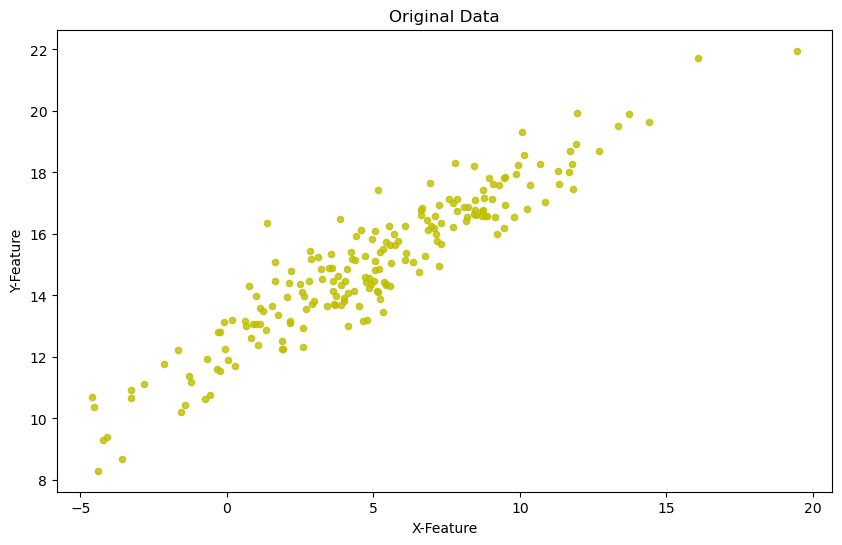

In [4]:
import numpy as np
import matplotlib.pyplot as plt 


np.random.seed(42)
n_points=200
mean=[5,15] # mean point
cov_matrix=[[19,10],[10,6]]
data=np.random.multivariate_normal(mean,cov_matrix,n_points)

x=data[:,0]
y=data[:,1]

w=np.random.rand()
b=np.random.rand()
eta=0.01
epochs=1000
mini_batch_size=32

costVal=[]
line_history=[]# store w,b 
save_interval=20

plt.figure(figsize=(10,6),dpi=100)
plt.scatter(x,y,alpha=0.8,s=20,c='y')
plt.xlabel("X-Feature")
plt.ylabel("Y-Feature")
plt.title("Original Data")
line_history.append((w,b))# this is the first fitted line that will be far from the optimal fitted line sice the w , b of this line are randoms



# Batch GD

In [7]:

for epoch in range(epochs):
    yhat= w * x + b

    error=yhat-y

    # d-> Deraivative -> rate of change 
    dw=np.mean(error*x)
    db=np.mean(error)

    #Move Toward Better Line 
    w=w-eta*dw
    b=b-eta*db

    # MSE cost
    # 0.5 convineance number for Deviation
    cost = 0.5* np.mean(error **2)
    costVal.append(cost)

    if epoch % save_interval ==0 and epoch >0:
        line_history.append((w,b))

    if cost < 1e-6:
        break    
       



# Visualisation

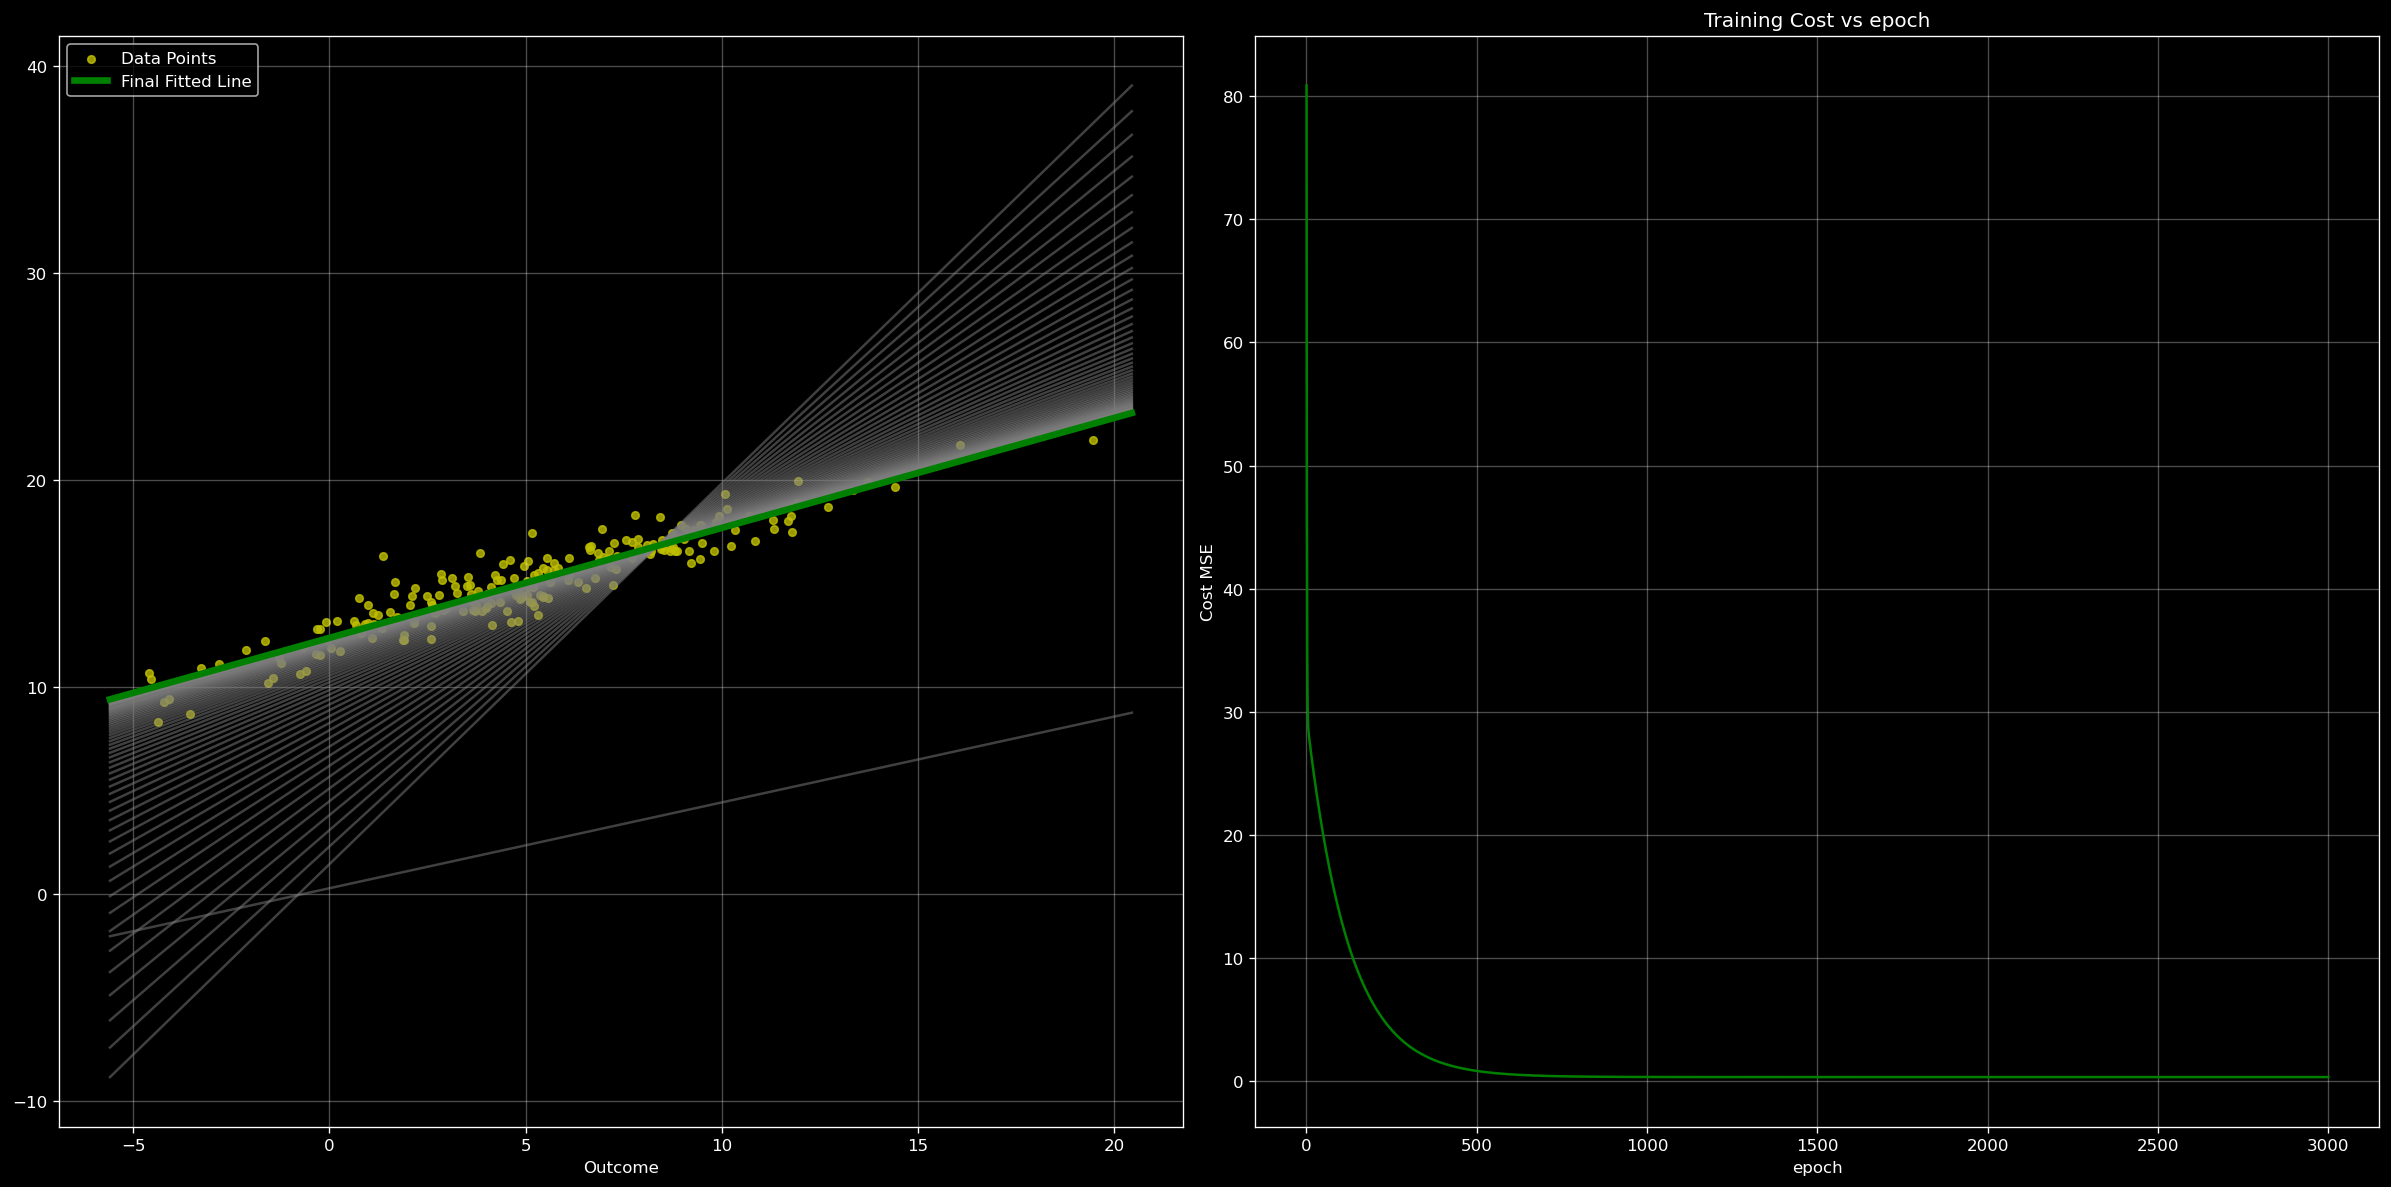

In [9]:
plt.style.use("dark_background")
plt.figure(figsize=(30,10),dpi=120)

plt.subplot(1,3,1)
plt.scatter(x,y,alpha=0.8,s=20,c='y',label="Data Points")
line_history.append((w,b))

# np.linespace() it generate 100 spaced number from start num  to  end num 
xvals=np.linspace(x.min()-1,x.max()+1,100)

# draw all fitted line instead last line that will be opitimal fitted line
for i,(w_hist,b_hist)in enumerate(line_history[:-1]):
    yvals_hist= w_hist* xvals + b_hist;
    plt.plot(xvals,yvals_hist,color='gray',alpha=0.5)

y_vals_final=w*xvals+b
plt.plot(xvals,y_vals_final,'g-',lw=4,label="Final Fitted Line")

plt.xlabel('X')
plt.xlabel('Outcome')
plt.legend()
plt.grid(True,alpha=0.3)

plt.subplot(1,3,2)
plt.plot(range(1,len(costVal)+1),costVal,'g')
plt.xlabel("epoch")
plt.ylabel("Cost MSE")
plt.title("Training Cost vs epoch")
plt.grid(alpha=0.3)
plt.tight_layout()



# Mini-Batch Gradient Descent (MBGD)





In [168]:
epoch=0
iterations=0 # how many time mode update w , b


while epoch<epochs:
    #create random ordering to numbers from 0 to len(x) excluded
    indices=np.random.permutation(len(x))
    # we shuffle the data to make sure the model will learn from rel between x ,y not from there order
    # in BGD see all dataset before update w,b so it doesn't be affected by orders of data 
    x_shuffled=x[indices]
    y_shuffled=y[indices]

    for start_idx in range(0,len(x),mini_batch_size):
        end_idx=min(start_idx + mini_batch_size,len(x))
        x_batch=x_shuffled[start_idx:end_idx]
        y_batch=y_shuffled[start_idx:end_idx]

        yhat_batch=(w*x_batch)+b

        dw=((yhat_batch-y_batch)@x_batch)/len(x_batch)
        db=np.mean(yhat_batch-y_batch)

        w=w-eta*dw
        b=b-eta*db

        iterations+=1

        if iterations % save_interval ==0:
            line_history.append((w,b))

    # now we evaluate the w,b we get from each batch  finished  to predict error for all dataset        
    yhat_full=(w*x)+b
    cost=0.5 *np.mean((yhat_full-y)**2)
    costVal.append(cost)

    if cost < 1e-6 :
        break
    epoch+=1        



# Stochastic Gradient Descent (SGD)





In [161]:
# epoch explain how many time the model process the entire dataset , iterations explain how many time w,b has been updated 
epoch=0
iterations=0


while epoch<epochs:
    #create random ordering to numbers from 0 to len(x) excluded
    indices=np.random.permutation(len(x))
    x_shuffled=x[indices]
    y_shuffled=y[indices]

    for j in range(len(x)):
        x_single=x_shuffled[j]
        y_single=y_shuffled[j]

        yhat_single=w*x_single +b
        # there is no mean because there is one sample only
        dw=(yhat_single-y_single)*x_single
        db=(yhat_single-y_single)

        w=w-eta*dw
        b=b-eta*db

        iterations+=1

        if iterations % (save_interval*10) ==0:
            line_history.append((w,b))
            
    yhat_full=(w*x)+b
    cost=0.5 *np.mean((yhat_full-y)**2)
    costVal.append(cost)

    if cost < 1e-6 :
        break
    epoch+=1             
              
